# NSMC 한국어 영화 리뷰 감정분석

klue/bert-base 모델을 NSMC 데이터셋으로 fine-tuning 하는 프로젝트.

## 목표 (제출 루브릭)
1. klue/bert-base + NSMC로 fine-tuning, 정상 작동 확인
2. Preprocessing 개선 + fine-tuning으로 Validation Accuracy 90% 이상
3. Bucketing 적용 → 연산 속도와 성능 간 trade-off 분석

- 입력: 한국어 리뷰 문장 1개 / 출력: 긍정(1) · 부정(0)
- 평가지표: Accuracy
- 데이터: NSMC (Hugging Face datasets로 자동 로드)

## 1. 라이브러리 임포트

In [ ]:
# ===== 환경 충돌 방지 (이 두 줄은 반드시 맨 위에!) =====
# OMP Error #15 (libiomp5md.dll 중복) 때문에 커널이 죽는 걸 막아줌
# 어떤 import 보다도 먼저 실행되어야 효과가 있음
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# [클라우드 수정] 아래 OMP 두 줄은 로컬 윈도우 충돌 방지용이라 클라우드(리눅스)에선 불필요 -> 삭제하거나 그냥 둬도 무해
# import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 나머지 import는 그대로 두기
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # 그래프 그리기
import seaborn as sns            # 더 예쁜 그래프 (히트맵 등)
import torch                     # 딥러닝 프레임워크 (PyTorch)

# datasets: HuggingFace에서 데이터를 불러오고 다루는 라이브러리
from datasets import load_dataset, Dataset

# transformers: BERT 같은 사전학습 모델을 쉽게 쓰게 해주는 라이브러리
from transformers import (
    AutoTokenizer,                          # 문장 -> 토큰 ID 변환기
    AutoModelForSequenceClassification,     # 문장 분류용 모델 (BERT + 분류헤드)
    TrainingArguments,                      # 학습 설정값 모음
    Trainer,                                # 학습/평가를 자동으로 돌려주는 도구
    DataCollatorWithPadding,                # 배치마다 길이를 맞춰주는(패딩) 도구
)

# sklearn: 성능 지표 계산용
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

sns.set(style="whitegrid")                  # 그래프 배경 스타일
plt.rcParams["figure.figsize"] = (8, 5)     # 그래프 기본 크기

# ===== 현재 환경 확인 (GPU가 잡히는지 꼭 확인!) =====
print("PyTorch:", torch.__version__)                  # 끝에 +cu124 붙어있으면 GPU 버전
print("GPU 사용 가능:", torch.cuda.is_available())     # True 여야 GPU로 빠르게 학습됨
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))  # NVIDIA GeForce RTX 3070 Ti

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.12.0+cu130
GPU 사용 가능: True
GPU 이름: NVIDIA GeForce RTX 5090


## 2. 데이터 로드

NSMC(Naver Sentiment Movie Corpus)도 Hugging Face에서 바로 불러옵니다.
컬럼: id / document(리뷰 문장) / label(0=부정, 1=긍정)

NSMC는 train/test 두 개만 있고 별도 validation이 없어서,
test 셋을 validation으로 사용합니다.

In [ ]:
# [확인] datasets 최신 버전은 스크립트 방식을 막아서 parquet 버전으로 로드
dataset = load_dataset("e9t/nsmc", revision="refs/convert/parquet")

Generating train split: 150000 examples [00:00, 449711.26 examples/s]
Generating test split: 50000 examples [00:00, 846831.18 examples/s]


In [ ]:
# 레이블 숫자를 사람이 읽기 쉬운 이름으로 매핑할 사전(dictionary)
LABELS = {0: "negative", 1: "positive"}   # 0=부정, 1=긍정

# 데이터 개수 확인
print("train:", len(dataset["train"]))
print("test :", len(dataset["test"]))

# 실제 리뷰가 어떻게 생겼는지 3개만 출력
print("\n--- train 예시 3개 ---")
for i in range(3):
    ex = dataset["train"][i]                       # i번째 샘플 가져오기
    # ex["document"]: 리뷰 문장, ex["label"]: 정답(0/1)
    print(f"[{LABELS[ex['label']]}] {ex['document']}")

train: 150000
test : 50000

--- train 예시 3개 ---
[negative] 아 더빙.. 진짜 짜증나네요 목소리
[positive] 흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
[negative] 너무재밓었다그래서보는것을추천한다


## 3. 탐색적 데이터 분석 (EDA)

In [ ]:
# HuggingFace Dataset을 pandas 표로 바꾸면 통계/시각화가 편함
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

# label(0/1) 옆에 사람이 읽을 수 있는 이름 컬럼 추가
train_df["label_name"] = train_df["label"].map(LABELS)

train_df.head()   # 위에서 5줄만 미리보기

,id,document,label,label_name
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0,negative
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1,positive
2,10265843,너무재밓었다그래서보는것을추천한다,0,negative
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0,negative
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1,positive


### 3-1. 레이블 분포

긍정/부정이 균형 잡혀 있는지 확인합니다. (NSMC는 거의 50:50 입니다)

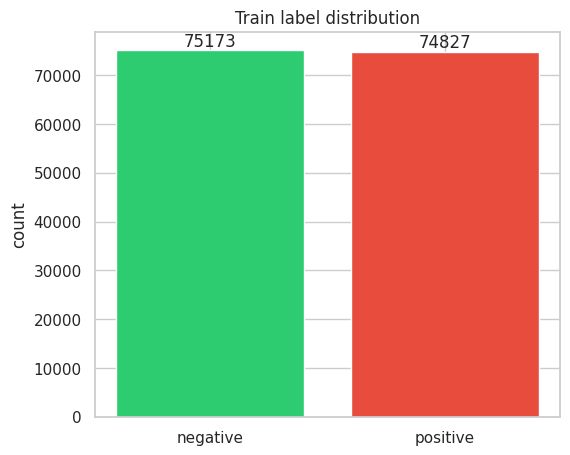

In [ ]:
plt.figure(figsize=(6, 5))

# 긍정/부정 각각 몇 개인지 세기
counts = train_df["label_name"].value_counts()

# 막대그래프: 긍정=초록, 부정=빨강
plt.bar(counts.index, counts.values, color=["#2ecc71", "#e74c3c"])
plt.title("Train label distribution")
plt.ylabel("count")

# 막대 위에 정확한 숫자 표시
for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom")

plt.show()
# 거의 50:50이면 클래스 불균형 문제가 없다는 뜻 (좋음)

## 4. Preprocessing 개선  ⭐ (루브릭 항목 2)

NSMC에는 두 가지 알려진 문제가 있습니다.
1. document가 비어있는(null) 행
2. 완전히 똑같이 중복된 리뷰

이걸 그대로 두면 학습에 노이즈가 됩니다. 제거해서 데이터 품질을 높입니다.
이것이 "preprocessing 개선" 입니다.

In [ ]:
# 데이터 정제 함수: 빈 문장 + 중복 문장을 제거
def clean_df(df):
    before = len(df)                 # 정제 전 개수 (얼마나 지워졌는지 비교용)
    df = df.copy()                   # 원본을 건드리지 않기 위해 복사본 사용

    # 1) 문장을 문자열로 바꾸고 양쪽 공백 제거
    df["document"] = df["document"].astype(str).str.strip()

    # 2) 내용이 비어있는(길이 0) 행 제거
    df = df[df["document"].str.len() > 0]

    # 3) null이 문자열 "nan"으로 바뀐 경우도 제거
    df = df[df["document"] != "nan"]

    # 4) 완전히 똑같은 리뷰(중복) 제거 -> 학습 노이즈 줄임
    df = df.drop_duplicates(subset=["document"])

    after = len(df)                  # 정제 후 개수
    print(f"{before} -> {after}  ({before - after}개 제거)")

    # 행을 지웠으니 인덱스를 0부터 다시 매김
    return df.reset_index(drop=True)

print("train 정제:")
train_clean = clean_df(train_df)
print("test 정제:")
test_clean = clean_df(test_df)

train 정제:
150000 -> 146182  (3818개 제거)
test 정제:
50000 -> 49157  (843개 제거)


In [ ]:
# 정제한 pandas 표를 다시 HuggingFace Dataset으로 변환
# (필요한 컬럼 document, label 만 골라서)
train_ds = Dataset.from_pandas(train_clean[["document", "label"]])
val_ds = Dataset.from_pandas(test_clean[["document", "label"]])   # test를 검증용으로 사용

print(train_ds)
print(val_ds)

Dataset({
    features: ['document', 'label'],
    num_rows: 146182
})
Dataset({
    features: ['document', 'label'],
    num_rows: 49157
})


## 5. 토크나이징

klue/bert-base의 한국어 토크나이저를 사용합니다.
NSMC 리뷰는 짧은 편이라 max_length=128이면 충분합니다.

In [ ]:
import sys
!{sys.executable} -m pip install hf_transfer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 18.3 MB/s  0:00:00 eta 0:00:01

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [ ]:
model_name = "klue/bert-base"   # 한국어로 사전학습된 BERT 모델

# 그 모델에 맞는 토크나이저 불러오기 (한국어 처리 규칙이 들어있음)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 문장을 토큰 ID로 바꾸는 함수
def tokenize_fn(examples):
    return tokenizer(
        examples["document"],   # 변환할 문장
        truncation=True,        # max_length보다 길면 잘라냄
        max_length=128,         # 최대 토큰 길이 (NSMC 리뷰는 짧아서 충분)
    )
    # 여기서는 일부러 padding을 안 함 -> 배치마다 동적으로 패딩(셀 17 collator가 처리)

# batched=True: 여러 문장을 한꺼번에 처리해서 빠름
train_tok = train_ds.map(tokenize_fn, batched=True)
val_tok = val_ds.map(tokenize_fn, batched=True)

# 토크나이징이 어떻게 됐는지 첫 문장으로 확인
print(train_ds[0]["document"])                                   # 원본 문장
print(tokenizer.convert_ids_to_tokens(train_tok[0]["input_ids"])) # 토큰으로 쪼갠 결과

Map: 100%|██████████| 49157/49157 [00:00<00:00, 53795.93 examples/s]

아 더빙.. 진짜 짜증나네요 목소리
['[CLS]', '아', '더', '##빙', '.', '.', '진짜', '짜증', '##나', '##네', '##요', '목소리', '[SEP]']


## 6. 학습 준비 (공통 설정)

평가지표 함수와 동적 패딩 collator를 정의합니다.
실험을 두 번(bucketing 끔/켬) 돌릴 거라서, 학습을 함수로 만들어 재사용합니다.

In [ ]:
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
# 모델 예측 결과로 성능 지표를 계산하는 함수 (Trainer가 평가할 때 자동 호출)
def compute_metrics(eval_pred):
    logits, labels = eval_pred              # logits: 모델 출력값, labels: 정답
    preds = np.argmax(logits, axis=-1)      # 둘 중 점수가 큰 쪽을 예측값으로
    return {
        "accuracy": accuracy_score(labels, preds),   # 정확도
        "f1": f1_score(labels, preds),               # F1 점수
    }

# 배치 안에서 가장 긴 문장에 맞춰 나머지를 패딩해주는 도구 (동적 패딩)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## 7. Bucketing 실험  ⭐ (루브릭 항목 3)

**Bucketing이란?**
배치를 만들 때 보통은 문장 길이가 제멋대로 섞여서, 짧은 문장에
패딩(빈칸)을 잔뜩 넣게 됩니다 → 계산 낭비.
비슷한 길이끼리 묶으면(bucketing) 패딩이 줄어 학습이 빨라집니다.

Trainer에서는 `group_by_length=True` 옵션 하나로 적용됩니다.

아래 함수로 **끔(False) vs 켬(True)** 두 번 학습해서
학습 시간과 정확도를 비교합니다.

In [ ]:
def run_experiment(group_by_length, tag):
    print(f"\n===== 실험: {tag} (group_by_length={group_by_length}) =====")
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    args = TrainingArguments(
        output_dir=f"./nsmc-{tag}",
        learning_rate=2e-5,
        per_device_train_batch_size=64,
        per_device_eval_batch_size=128,
        num_train_epochs=2,
        weight_decay=0.01,
        logging_steps=200,
        save_strategy="no",
        disable_tqdm=True,
        report_to="none",
        group_by_length=group_by_length,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    train_result = trainer.train()
    eval_result = trainer.evaluate()

    return {
        "setting": tag,
        "train_runtime(s)": round(train_result.metrics["train_runtime"], 1),
        "accuracy": round(eval_result["eval_accuracy"], 4),
        "f1": round(eval_result["eval_f1"], 4),
    }, trainer

In [ ]:
import datasets
datasets.disable_progress_bars()

from transformers.utils import logging as hf_logging
hf_logging.disable_progress_bar()

In [ ]:
result_base, trainer_base = run_experiment(group_by_length=False, tag="baseline")
result_bucket, trainer_bucket = run_experiment(group_by_length=True, tag="bucketing")


===== 실험: baseline (group_by_length=False) =====


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'loss': 0.374, 'grad_norm': 5.51401948928833, 'learning_rate': 1.912472647702407e-05, 'epoch': 0.087527352297593}
{'loss': 0.3006, 'grad_norm': 3.266618251800537, 'learning_rate': 1.824945295404814e-05, 'epoch': 0.175054704595186}
{'loss': 0.2871, 'grad_norm': 3.699978828430176, 'learning_rate': 1.737417943107221e-05, 'epoch': 0.26258205689277897}
{'loss': 0.2804, 'grad_norm': 2.767083168029785, 'learning_rate': 1.649890590809628e-05, 'epoch': 0.350109409190372}
{'loss': 0.2718, 'grad_norm': 2.9225332736968994, 'learning_rate': 1.562363238512035e-05, 'epoch': 0.437636761487965}
{'loss': 0.2637, 'grad_norm': 3.4000682830810547, 'learning_rate': 1.4748358862144421e-05, 'epoch': 0.5251641137855579}
{'loss': 0.2637, 'grad_norm': 4.25326681137085, 'learning_rate': 1.387308533916849e-05, 'epoch': 0.612691466083151}
{'loss': 0.2506, 'grad_norm': 4.582780838012695, 'learning_rate': 1.299781181619256e-05, 'epoch': 0.700218818380744}
{'loss': 0.2545, 'grad_norm': 2.9816648960113525, 'learning_r

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


{'loss': 0.3757, 'grad_norm': 4.7229108810424805, 'learning_rate': 1.912472647702407e-05, 'epoch': 0.087527352297593}
{'loss': 0.3112, 'grad_norm': 4.056926250457764, 'learning_rate': 1.824945295404814e-05, 'epoch': 0.175054704595186}
{'loss': 0.2942, 'grad_norm': 6.560693264007568, 'learning_rate': 1.737417943107221e-05, 'epoch': 0.26258205689277897}
{'loss': 0.2808, 'grad_norm': 3.5239455699920654, 'learning_rate': 1.649890590809628e-05, 'epoch': 0.350109409190372}
{'loss': 0.277, 'grad_norm': 3.57948637008667, 'learning_rate': 1.562363238512035e-05, 'epoch': 0.437636761487965}
{'loss': 0.2769, 'grad_norm': 3.939052104949951, 'learning_rate': 1.4748358862144421e-05, 'epoch': 0.5251641137855579}
{'loss': 0.2676, 'grad_norm': 2.5798399448394775, 'learning_rate': 1.387308533916849e-05, 'epoch': 0.612691466083151}
{'loss': 0.2525, 'grad_norm': 5.225744247436523, 'learning_rate': 1.299781181619256e-05, 'epoch': 0.700218818380744}
{'loss': 0.2583, 'grad_norm': 4.280458927154541, 'learning_

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


{'train_runtime': 155.4338, 'train_samples_per_second': 1880.955, 'train_steps_per_second': 29.402, 'train_loss': 0.23323859250258563, 'epoch': 2.0}
{'eval_loss': 0.24202801287174225, 'eval_accuracy': 0.9054865024309864, 'eval_f1': 0.9066505927265421, 'eval_runtime': 6.5661, 'eval_samples_per_second': 7486.529, 'eval_steps_per_second': 58.635, 'epoch': 2.0}


### 7-1. Trade-off 분석

두 실험의 학습 시간과 정확도를 비교합니다.
기대: bucketing을 켜면 **학습 시간은 줄고, 정확도는 거의 비슷**해야 함.

     setting  train_runtime(s)  accuracy      f1
0   baseline             313.9    0.9065  0.9077
1  bucketing             155.4    0.9055  0.9067


/tmp/ipykernel_5813/1950323885.py:19: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5813/1950323885.py:19: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/root/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/root/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


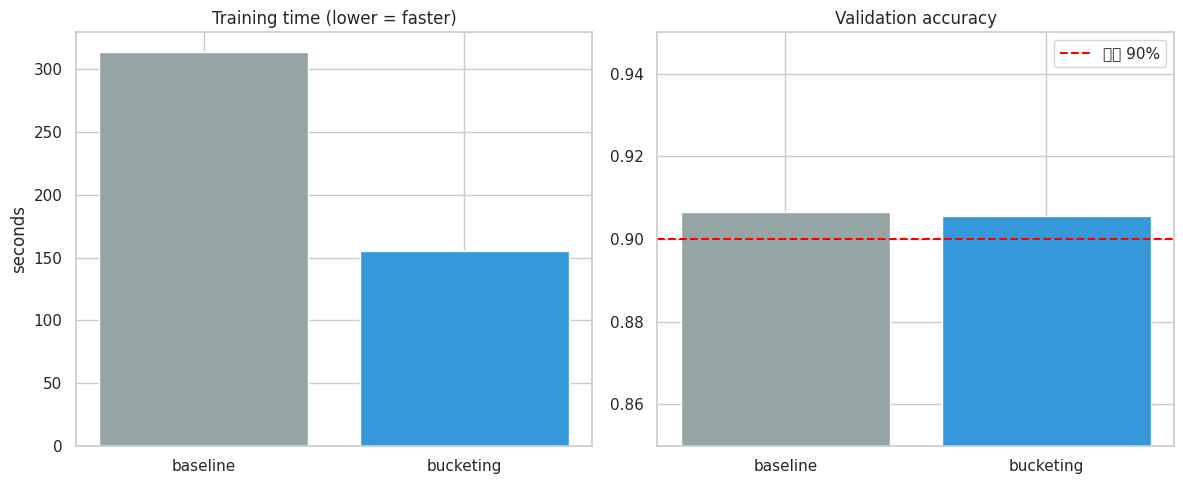

In [ ]:
# 두 실험 결과를 한 표로 합치기
compare = pd.DataFrame([result_base, result_bucket])
print(compare)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))   # 그래프 2개 나란히

# 왼쪽: 학습 시간 비교 (낮을수록 빠름 = 좋음)
axes[0].bar(compare["setting"], compare["train_runtime(s)"], color=["#95a5a6", "#3498db"])
axes[0].set_title("Training time (lower = faster)")
axes[0].set_ylabel("seconds")

# 오른쪽: 정확도 비교
axes[1].bar(compare["setting"], compare["accuracy"], color=["#95a5a6", "#3498db"])
axes[1].set_ylim(0.85, 0.95)                       # y축 범위 좁혀서 차이 잘 보이게
axes[1].set_title("Validation accuracy")
axes[1].axhline(0.90, color="red", linestyle="--", label="목표 90%")  # 90% 기준선
axes[1].legend()

plt.tight_layout()
plt.show()
# 해석: 시간은 줄고(bucketing 효과) 정확도는 거의 그대로면 -> 좋은 trade-off

## 8. 평가 (성능 좋은 모델로)

혼동 행렬과 상세 지표를 확인합니다.
(baseline / bucketing 중 정확도 높은 trainer를 사용)

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


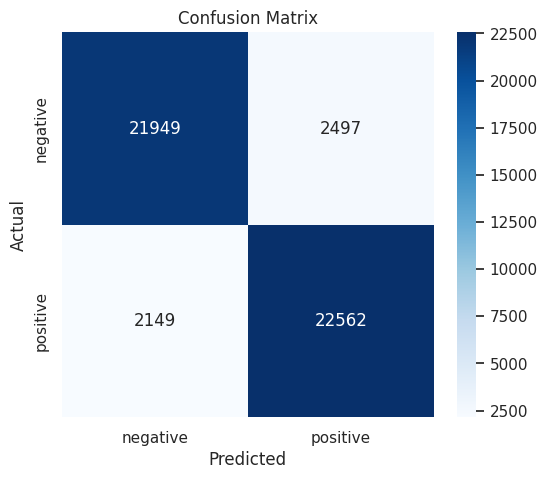

              precision    recall  f1-score   support

    negative       0.91      0.90      0.90     24446
    positive       0.90      0.91      0.91     24711

    accuracy                           0.91     49157
   macro avg       0.91      0.91      0.91     49157
weighted avg       0.91      0.91      0.91     49157



In [ ]:
best_trainer = trainer_base if result_base["accuracy"] >= result_bucket["accuracy"] else trainer_bucket

# 검증셋 전체에 대해 예측 수행
pred = best_trainer.predict(val_tok)
preds = np.argmax(pred.predictions, axis=-1)   # 예측값
true = pred.label_ids                          # 실제 정답

# 혼동 행렬: 모델이 어디서 헷갈렸는지 보여주는 표
cm = confusion_matrix(true, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",   # annot=숫자표시, fmt="d"=정수
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

# 정밀도/재현율/F1을 클래스별로 자세히 출력
print(classification_report(true, preds, target_names=["negative", "positive"]))

## 9. 직접 문장으로 예측해보기

In [ ]:
# 아무 문장이나 넣어서 긍정/부정 예측하는 함수
def predict_sentiment(text):
    # 입력 문장을 토큰으로 변환 (return_tensors="pt": PyTorch 텐서로)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    # 모델이 있는 장치(GPU/CPU)로 입력을 옮김
    inputs = {k: v.to(best_trainer.model.device) for k, v in inputs.items()}

    with torch.no_grad():                      # 예측만 할 거라 기울기 계산 끔(빠름)
        logits = best_trainer.model(**inputs).logits

    probs = torch.softmax(logits, dim=-1)[0]   # 점수를 확률로 변환
    pred = probs.argmax().item()               # 가장 확률 높은 클래스
    return LABELS[pred], probs[pred].item()    # (예측 라벨, 확신도) 반환

# 테스트용 문장들
samples = [
    "이 영화 정말 재미있어요 강력 추천합니다",
    "시간 아까운 최악의 영화였다",
    "배우 연기는 좋았는데 스토리가 너무 지루했어요",
]
for s in samples:
    label, conf = predict_sentiment(s)
    print(f"[{label}] ({conf:.2%})  {s}")

[positive] (99.01%)  이 영화 정말 재미있어요 강력 추천합니다
[negative] (99.90%)  시간 아까운 최악의 영화였다
[negative] (99.82%)  배우 연기는 좋았는데 스토리가 너무 지루했어요


## 9. 회고

### 프로젝트 요약
- 모델: klue/bert-base, 2 epochs
- 데이터: NSMC (train 15만 / test 5만), test 셋을 validation으로 사용
- 환경: RunPod RTX 5090 (클라우드 GPU)

### Preprocessing 개선 (루브릭 2)
- 빈 문장(null)과 중복 리뷰 제거
  - train: 150,000 → 146,182 (3,818개 제거)
  - test: 50,000 → 49,157 (843개 제거)
- 노이즈를 줄여 데이터 품질을 높임

### Validation Accuracy (루브릭 2) — 목표 90% 달성 ✅
- baseline: 90.65% (F1 0.9077)
- bucketing: 90.55% (F1 0.9067)
- 두 설정 모두 목표치 90%를 넘김

### Bucketing Trade-off 분석 (루브릭 3)

| 설정 | 학습 시간 | Accuracy | F1 |
|------|-----------|----------|-----|
| baseline (bucketing 끔) | 313.9초 | 0.9065 | 0.9077 |
| bucketing (켬) | 155.4초 | 0.9055 | 0.9067 |

- 학습 시간: 313.9초 → 155.4초 (약 50% 단축)
- 정확도: 90.65% → 90.55% (0.1%p 차이로 거의 동일)
- 결론: bucketing을 적용하니 학습 속도가 약 2배 빨라졌고, 정확도 손실은 사실상 없었다. 비슷한 길이의 문장끼리 묶어 패딩 낭비를 줄인 효과가 명확하게 나타난 것으로, 속도와 성능 사이에서 매우 유리한 trade-off를 보였다.

### 배운 점 / 어려웠던 점
- 로컬 환경 세팅(PyTorch GPU, 라이브러리 버전 충돌, OMP 에러 등)에서 많은 시행착오를 겪었고, 결국 클라우드 GPU(RunPod)로 전환하여 안정적으로 학습을 완료함.
- transformers / torch / numpy 간 버전 호환의 중요성을 체감함.
- save_strategy='no'로 체크포인트 저장을 끄고, disable_tqdm으로 위젯 오류를 피하는 등 환경에 맞는 학습 설정 조정 방법을 익힘.